# EDA — commissariats.csv
Urban Data Explorer · Sécurité

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [13]:
# ⚠️ Change le chemin si besoin
# Modifie le chemin pour être sûr de l'orthographe exacte
FILE = '../brute/Score densité de services du quotidien/cartographie-des-emplacements-des-commissariats-a-paris-et-petite-couronne.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
print(f'Shape : {df.shape}')
df.head()

Shape : (93, 4)


,name,description,geometry,geo_point_2d
0,ANTONY,Commissariat central,"{""coordinates"": [2.2975939, 48.7604272], ""type...","48.7604272,2.2975939"
1,NaN,NaN,"{""coordinates"": [2.347822, 48.861506], ""type"":...","48.861506,2.347822"
2,MONTREUIL,Commissariat central,"{""coordinates"": [2.4425793, 48.8643099], ""type...","48.8643099,2.4425793"
3,BOULOGNE BILLANCOURT,Commissariat central,"{""coordinates"": [2.2408952, 48.8352357], ""type...","48.8352357,2.2408952"
4,CRETEIL / Bonneuil sur marne,Commissariat central,"{""coordinates"": [2.4579846, 48.7759521], ""type...","48.7759521,2.4579846"


## 2. Extraction des coordonnées (geometry GeoJSON)

In [7]:
# Le champ geometry contient du GeoJSON : on en extrait latitude / longitude
def parse_geometry(val):
    try:
        g = json.loads(val)
        lon, lat = g['coordinates']
        return pd.Series({'longitude': lon, 'latitude': lat})
    except Exception:
        return pd.Series({'longitude': np.nan, 'latitude': np.nan})

df[['longitude', 'latitude']] = df['geometry'].apply(parse_geometry)

# Coherence avec geo_point_2d (format 'lat,lon')
geo = df['geo_point_2d'].str.split(',', expand=True).astype(float)
ecart = (geo[0] - df['latitude']).abs().max()
print(f'Ecart max geometry vs geo_point_2d : {ecart:.2e}')
df[['name', 'latitude', 'longitude']].head()

Ecart max geometry vs geo_point_2d : 4.78e-11


,name,latitude,longitude
0,ANTONY,48.760427,2.297594
1,NaN,48.861506,2.347822
2,MONTREUIL,48.864310,2.442579
3,BOULOGNE BILLANCOURT,48.835236,2.240895
4,CRETEIL / Bonneuil sur marne,48.775952,2.457985


## 3. Infos générales

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          66 non-null     object 
 1   description   66 non-null     object 
 2   geometry      93 non-null     object 
 3   geo_point_2d  93 non-null     object 
 4   longitude     93 non-null     float64
 5   latitude      93 non-null     float64
dtypes: float64(2), object(4)
memory usage: 4.5+ KB


In [9]:
df.describe(include='all')

,name,description,geometry,geo_point_2d,longitude,latitude
count,66,66,93,93,93.000000,93.000000
unique,66,3,91,91,NaN,NaN
top,ANTONY,Commissariat central,"{""coordinates"": [2.2975939, 48.7604272], ""type...","48.7604272,2.2975939",NaN,NaN
freq,1,64,2,2,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.365044,48.860791
std,NaN,NaN,NaN,NaN,0.093020,0.051013
min,NaN,NaN,NaN,NaN,2.178015,48.736405
25%,NaN,NaN,NaN,NaN,2.297594,48.823374
50%,NaN,NaN,NaN,NaN,2.351680,48.865263
75%,NaN,NaN,NaN,NaN,2.437379,48.893658


## 4. Valeurs manquantes

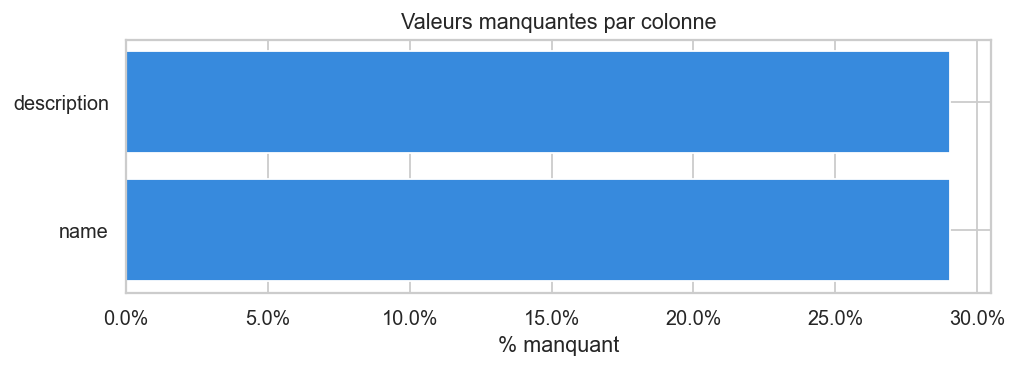

,% manquant
name,29.032258
description,29.032258


In [10]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    ax.barh(missing.index, missing.values, color='#378ADD')
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()
    display(missing.rename('% manquant').to_frame())

## 5. Doublons

In [11]:
n_dup = df.duplicated().sum()
print(f'Doublons exacts        : {n_dup} ({n_dup/len(df)*100:.2f}%)')
n_dup_geo = df.duplicated(subset=['latitude','longitude']).sum()
print(f'Doublons sur coordonnees : {n_dup_geo} ({n_dup_geo/len(df)*100:.2f}%)')
if n_dup_geo > 0:
    display(df[df.duplicated(subset=['latitude','longitude'], keep=False)]
            .sort_values(['latitude','longitude'])[['name','description','latitude','longitude']].head(10))

Doublons exacts        : 0 (0.00%)
Doublons sur coordonnees : 2 (2.15%)


,name,description,latitude,longitude
0,ANTONY,Commissariat central,48.760427,2.297594
38,ANTONY / Bourg La Reine,Commissariat central,48.760427,2.297594
13,ASNIERES sur SEINE,Commissariat central,48.906630,2.287535
40,Asnieres sur Seines / Bois Colombes,Commissariat central,48.906630,2.287535


## 6. Détection des colonnes clés

In [12]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'name'        : find_col(df, 'name', 'nom'),
    'description' : find_col(df, 'description', 'desc', 'type'),
    'latitude'    : find_col(df, 'latitude', 'lat'),
    'longitude'   : find_col(df, 'longitude', 'lon', 'lng'),
}
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'{status}  {k:14s} → {v}')

✅  name           → name
✅  description    → description
✅  latitude       → latitude
✅  longitude      → longitude


## 7. Distribution géographique

Points dans Paris intra-muros (approx) : 90
Points en IDF                          : 93
Hors IDF                               : 0


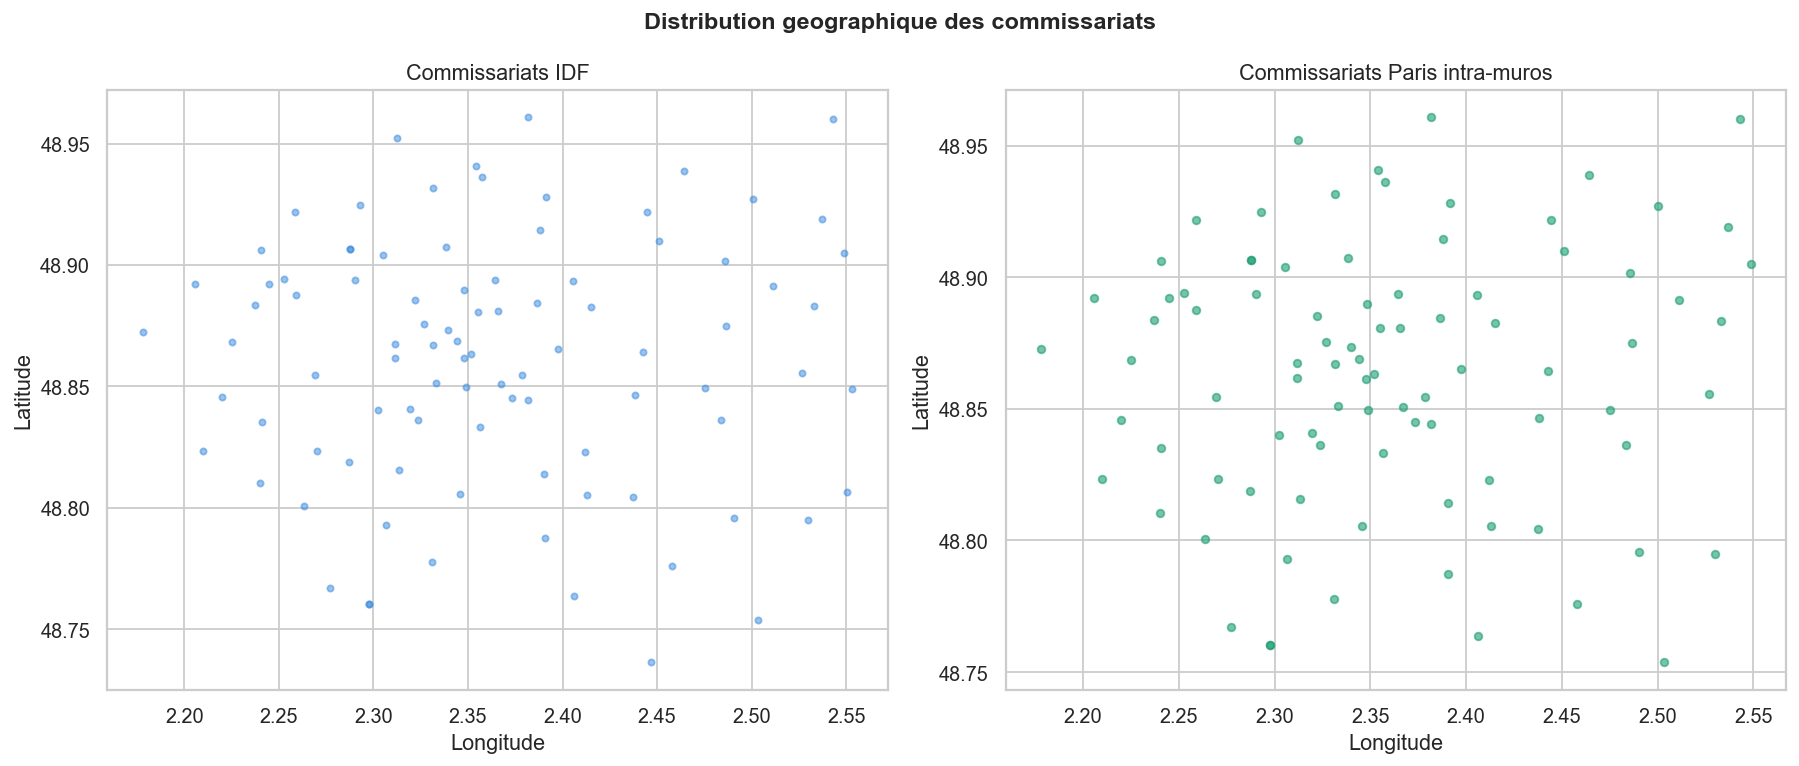

In [15]:
lat_col, lon_col = col_map['latitude'], col_map['longitude']
if lat_col and lon_col:
    geo = df[[lat_col, lon_col]].dropna()
    paris = geo[(geo[lat_col].between(48.75, 49.05)) & (geo[lon_col].between(2.1, 2.55))]
    idf   = geo[(geo[lat_col].between(48.0, 49.4))  & (geo[lon_col].between(1.4, 3.6))]

    print(f'Points dans Paris intra-muros (approx) : {len(paris):,}')
    print(f'Points en IDF                          : {len(idf):,}')
    print(f'Hors IDF                               : {len(geo) - len(idf):,}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(idf[lon_col], idf[lat_col], s=12, alpha=0.5, color='#378ADD')
    axes[0].set_title('Commissariats IDF')
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
    axes[1].scatter(paris[lon_col], paris[lat_col], s=18, alpha=0.6, color='#1D9E75')
    axes[1].set_title('Commissariats Paris intra-muros')
    axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
    plt.suptitle('Distribution geographique des commissariats', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonnes lat/lon non trouvees')

## 11. Résumé final

In [17]:
print('=' * 50)
print('RESUME EDA — commissariats.csv')
print('=' * 50)
print(f'  Lignes          : {len(df):,}')
print(f'  Colonnes        : {len(df.columns)}')
print(f'  Doublons exacts : {df.duplicated().sum()}')
print(f'  Doublons coords : {df.duplicated(subset=["latitude","longitude"]).sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN   : {missing_count}')
print(f'  Lignes sans nom : {df["name"].isna().sum()}')
if lat_col and lon_col:
    print(f'  Lat range       : {df[lat_col].min():.4f} → {df[lat_col].max():.4f}')
    print(f'  Lon range       : {df[lon_col].min():.4f} → {df[lon_col].max():.4f}')
print('=' * 50)

RESUME EDA — commissariats.csv
  Lignes          : 93
  Colonnes        : 6
  Doublons exacts : 0
  Doublons coords : 2
  Cols avec NaN   : 2
  Lignes sans nom : 27
  Lat range       : 48.7364 → 48.9608
  Lon range       : 2.1780 → 2.5532
